## Tackling Fashion MNIST with CNN architecture

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from pathlib import Path

The AlexNet architecture was originally designed for 224x224 images, but a careful look into the first layer shows that the images are in fact 227 x 227.

So we first reshape the images (originally 28x28) to 227 x 227 

In [3]:
# transgform images to 224x224
scale_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Downloading the data
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=scale_transform
)
test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=scale_transform
)
print(f'Train data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

Train data size: 60000
Test data size: 10000


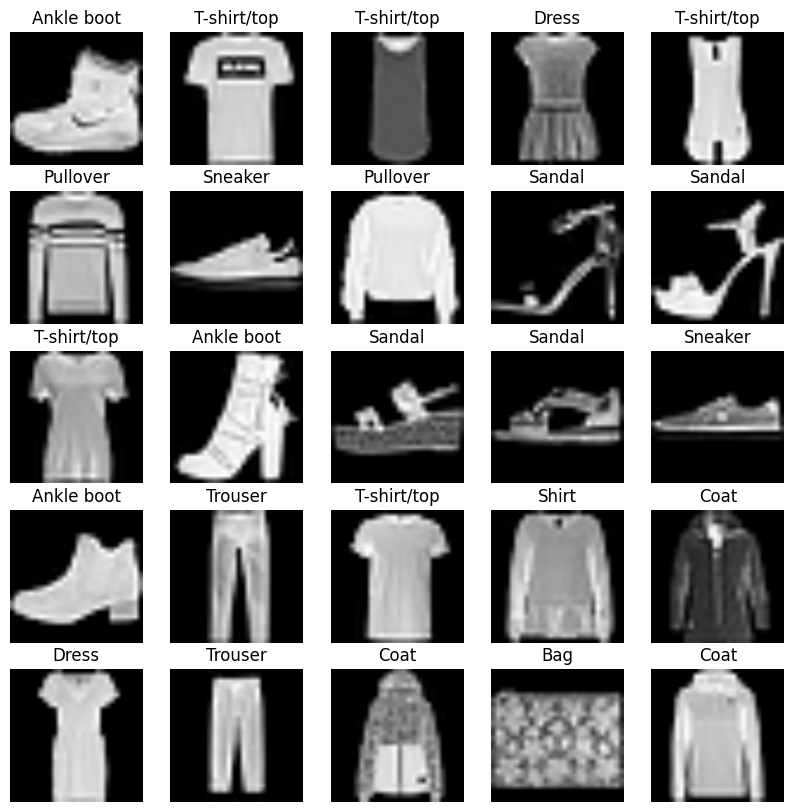

In [4]:
# visualising some images in a 5x5 grid
fig, axs = plt.subplots(5, 5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        image = train_data[i*5+j][0][0]
        label = train_data.classes[train_data[i*5+j][1]]
        axs[i, j].imshow(image, cmap='grey')
        axs[i, j].set_title(label)
        axs[i, j].axis('off')
plt.show()

In [5]:
torch.xpu.is_available()
device = torch.device('xpu')
device

device(type='xpu')

In [ ]:
alexnet = nn.Sequential(
    nn.Conv2d(1, 96, 11, stride=4),    # 96x55x55
    nn.ReLU(),
    nn.MaxPool2d(3, stride=2),         # 96x27x27
    nn.Conv2d(96, 256, 5, padding=2),  # 256x27x27
    nn.ReLU(),
    nn.MaxPool2d(3, stride=2),         # 256x13x13
    nn.Conv2d(256, 384, 3, padding=1), # 384x13x13
    nn.ReLU(),
    nn.Conv2d(384, 384, 3, padding=1), # 384x13x13
    nn.ReLU(),
    nn.Conv2d(384, 256, 3, padding=1), # 256x13x13
    nn.ReLU(),
    nn.MaxPool2d(3, stride=2),         # 256x6x6
    nn.Flatten(),                      # 9216
    nn.Linear(6*6*256, 4096),          # 4096
    nn.ReLU(),
    nn.Linear(4096, 256),              # 256
    nn.ReLU(),
    nn.Linear(256, 10),                # 10
)

# load model state if file exists
filepath = Path('alexnet_model.pt')
if filepath.is_file():
  alexnet.load_state_dict(torch.load('alexnet_model.pt'))

In [44]:
# for debugging
def print_sizes(model, input_tensor):
    output = input_tensor
    print('Input:', output.shape)
    for m in model.children():
        output = m(output)
        print(m)
        print(output.shape)
    return output

def train_model(model, filename, train_loader, test_loader, optimizer, loss_fn, epochs=10):
    model.to(device)
    train_acc = []
    test_acc = []
    train_losses = []
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            # print_sizes(model, data)
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()
            
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Batch {batch_idx}, '
                      f'Loss: {loss.item():.4f}')
        
        # Calculate training accuracy
        train_accuracy = 100 * correct_train / total_train
        train_acc.append(train_accuracy)
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Validation phase
        model.eval()
        correct_test = 0
        total_test = 0
        test_loss = 0.0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                test_loss += loss_fn(output, target).item()
                _, predicted = torch.max(output.data, 1)
                total_test += target.size(0)
                correct_test += (predicted == target).sum().item()
        
        test_accuracy = 100 * correct_test / total_test
        test_acc.append(test_accuracy)
        avg_test_loss = test_loss / len(test_loader)
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train Loss: {avg_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
        print(f'  Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')
        print('-' * 60)

        # Saving model
        torch.save(model.state_dict(), filename)
        print('Saved model')
    return train_losses, train_acc, test_acc

batch_size = 64
optimizer = torch.optim.Adam(alexnet.parameters())
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

train_losses, train_acc, test_acc = train_model(alexnet, train_loader, test_loader, optimizer, loss_fn, 20)

plt.plot(train_losses)
plt.show()

plt.plot(train_acc, label='Training accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.legend()

RuntimeError: Given input size: (256x2x2). Calculated output size: (256x0x0). Output size is too small

odict_keys(['0.weight', '0.bias', '3.weight', '3.bias', '6.weight', '6.bias', '8.weight', '8.bias', '10.weight', '10.bias', '14.weight', '14.bias', '16.weight', '16.bias', '18.weight', '18.bias'])


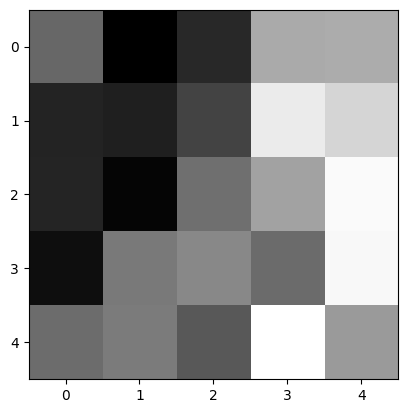

In [ ]:
jjstate = alexnet.state_dict()
print(state.keys())
plt.imshow(state['3.weight'].cpu()[3][0], 'grey')

AlexNet maxes out around 91% accuracy. I feel the network is too complex and is overfitting on the train data despite using dropout.

To test this, I'll try to fit LeNet which was designed specifically for 28x28 MNIST images to see if we get better results.

In [36]:
lenet = nn.Sequential(
    nn.Conv2d(1, 6, 5, padding=2), # 6x28x28
    nn.Sigmoid(),
    nn.MaxPool2d(2, stride=2),     # 6x10x10
    nn.Conv2d(6, 16, 5),
    nn.Sigmoid(),
    nn.MaxPool2d(2, stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10)
)

# load model state if file exists
filepath = Path('lenet_model.pt')
if filepath.is_file():
  lenet.load_state_dict(torch.load('lenet_model.pt'))

Epoch 1/30, Batch 0, Loss: 0.1648
Epoch 1/30, Batch 100, Loss: 0.2453
Epoch 1/30, Batch 200, Loss: 0.1072
Epoch 1/30, Batch 300, Loss: 0.1827
Epoch 1/30, Batch 400, Loss: 0.1158
Epoch 1/30, Batch 500, Loss: 0.2403
Epoch 1/30, Batch 600, Loss: 0.2715
Epoch 1/30, Batch 700, Loss: 0.1104
Epoch 1/30, Batch 800, Loss: 0.1632
Epoch 1/30, Batch 900, Loss: 0.1860
Epoch 1/30:
  Train Loss: 0.2315, Train Acc: 91.35%
  Test Loss: 0.2851, Test Acc: 89.43%
------------------------------------------------------------
Saved model
Epoch 2/30, Batch 0, Loss: 0.1913
Epoch 2/30, Batch 100, Loss: 0.2416
Epoch 2/30, Batch 200, Loss: 0.1896
Epoch 2/30, Batch 300, Loss: 0.3551
Epoch 2/30, Batch 400, Loss: 0.1399
Epoch 2/30, Batch 500, Loss: 0.4155
Epoch 2/30, Batch 600, Loss: 0.2599
Epoch 2/30, Batch 700, Loss: 0.1106
Epoch 2/30, Batch 800, Loss: 0.1351
Epoch 2/30, Batch 900, Loss: 0.1556
Epoch 2/30:
  Train Loss: 0.2310, Train Acc: 91.39%
  Test Loss: 0.2852, Test Acc: 89.60%
-------------------------------

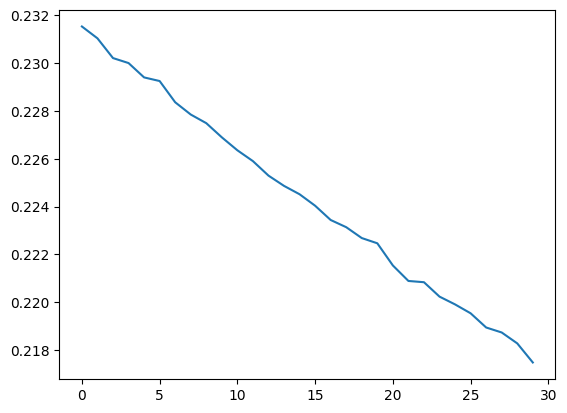

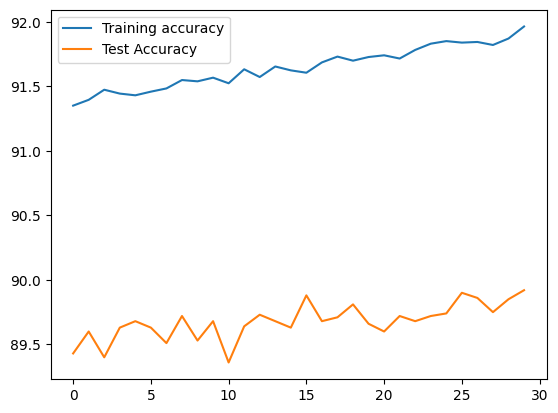

In [46]:
# Import data without rescaling
train_data_lenet = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
test_data_lenet = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)
batch_size = 64
optimizer_lenet = torch.optim.Adam(lenet.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()
train_loader_lenet = DataLoader(train_data_lenet, batch_size=batch_size, shuffle=True)
test_loader_lenet = DataLoader(test_data_lenet, batch_size=batch_size, shuffle=True)

train_losses, train_acc, test_acc = train_model(lenet, 'lenet_model.pt', train_loader_lenet, test_loader_lenet, optimizer_lenet, loss_fn, 30)

plt.plot(train_losses)
plt.show()

plt.plot(train_acc, label='Training accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.legend()

It appears I was wrong.